In [1]:
# ===============================================================
# 1. Import Libraries
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer



In [2]:
# ===============================================================
# 2. Load MPG Dataset
# ===============================================================

df = sns.load_dataset("mpg").dropna()
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Convert horsepower to numeric (fix '?' issues if any)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop rows with all NA in essential columns
df = df.dropna(subset=['mpg'])

# Separate features & target
X = df.drop(columns=['mpg'])
y = df['mpg']

# Identify numeric & categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_features, categorical_features

(Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
        'model_year'],
       dtype='object'),
 Index(['origin', 'name'], dtype='object'))

In [4]:
# ===============================================================
# 4. Preprocessing Pipelines
# ===============================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [5]:
# ===============================================================
# 5. Train-Test Split
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
# ===============================================================
# 6. Model Pipelines
# ===============================================================

# Linear Regression Model
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Random Forest Model
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=300, random_state=42))
    ]
)

In [7]:
# ===============================================================
# 7. Train the Models
# ===============================================================

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['origin', 'name'], dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [8]:
# ===============================================================
# 8. Predictions
# ===============================================================

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)


In [9]:
# ===============================================================
# 9. Evaluation Metrics
# ===============================================================

def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)


===== Linear Regression =====
R2 Score: 0.7032214169403863
RMSE: 3.8920113016875377

===== Random Forest =====
R2 Score: 0.8975026799518526
RMSE: 2.287252280746615


In [10]:
# ===============================================================
# 10. Feature Importance (Random Forest)
# ===============================================================

# Extract feature names after preprocessing
onehot_cols = list(
    rf_model.named_steps['preprocessor']
        .transformers_[1][1]
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
)

all_features = list(numeric_features) + onehot_cols

importances = rf_model.named_steps['regressor'].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(feat_imp.head())


Top Important Features:
        Feature  Importance
1  displacement    0.414752
2    horsepower    0.165490
3        weight    0.134645
0     cylinders    0.133476
5    model_year    0.094619


--- Exploratory Data Analysis (EDA) Visualizations ---


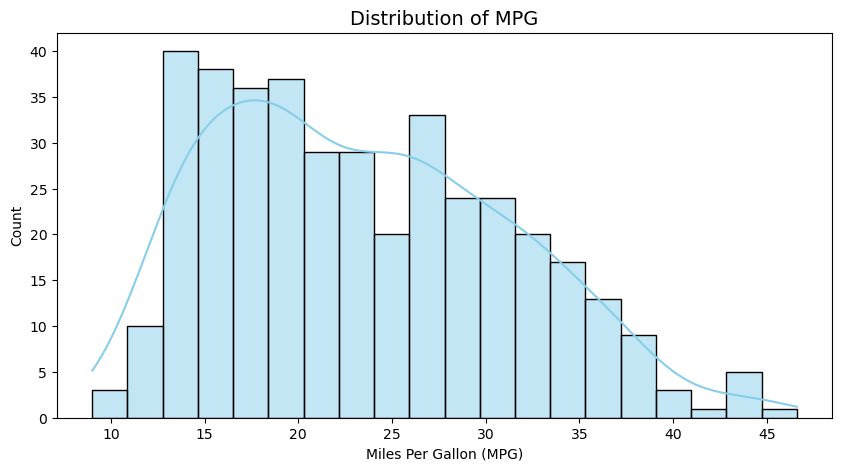

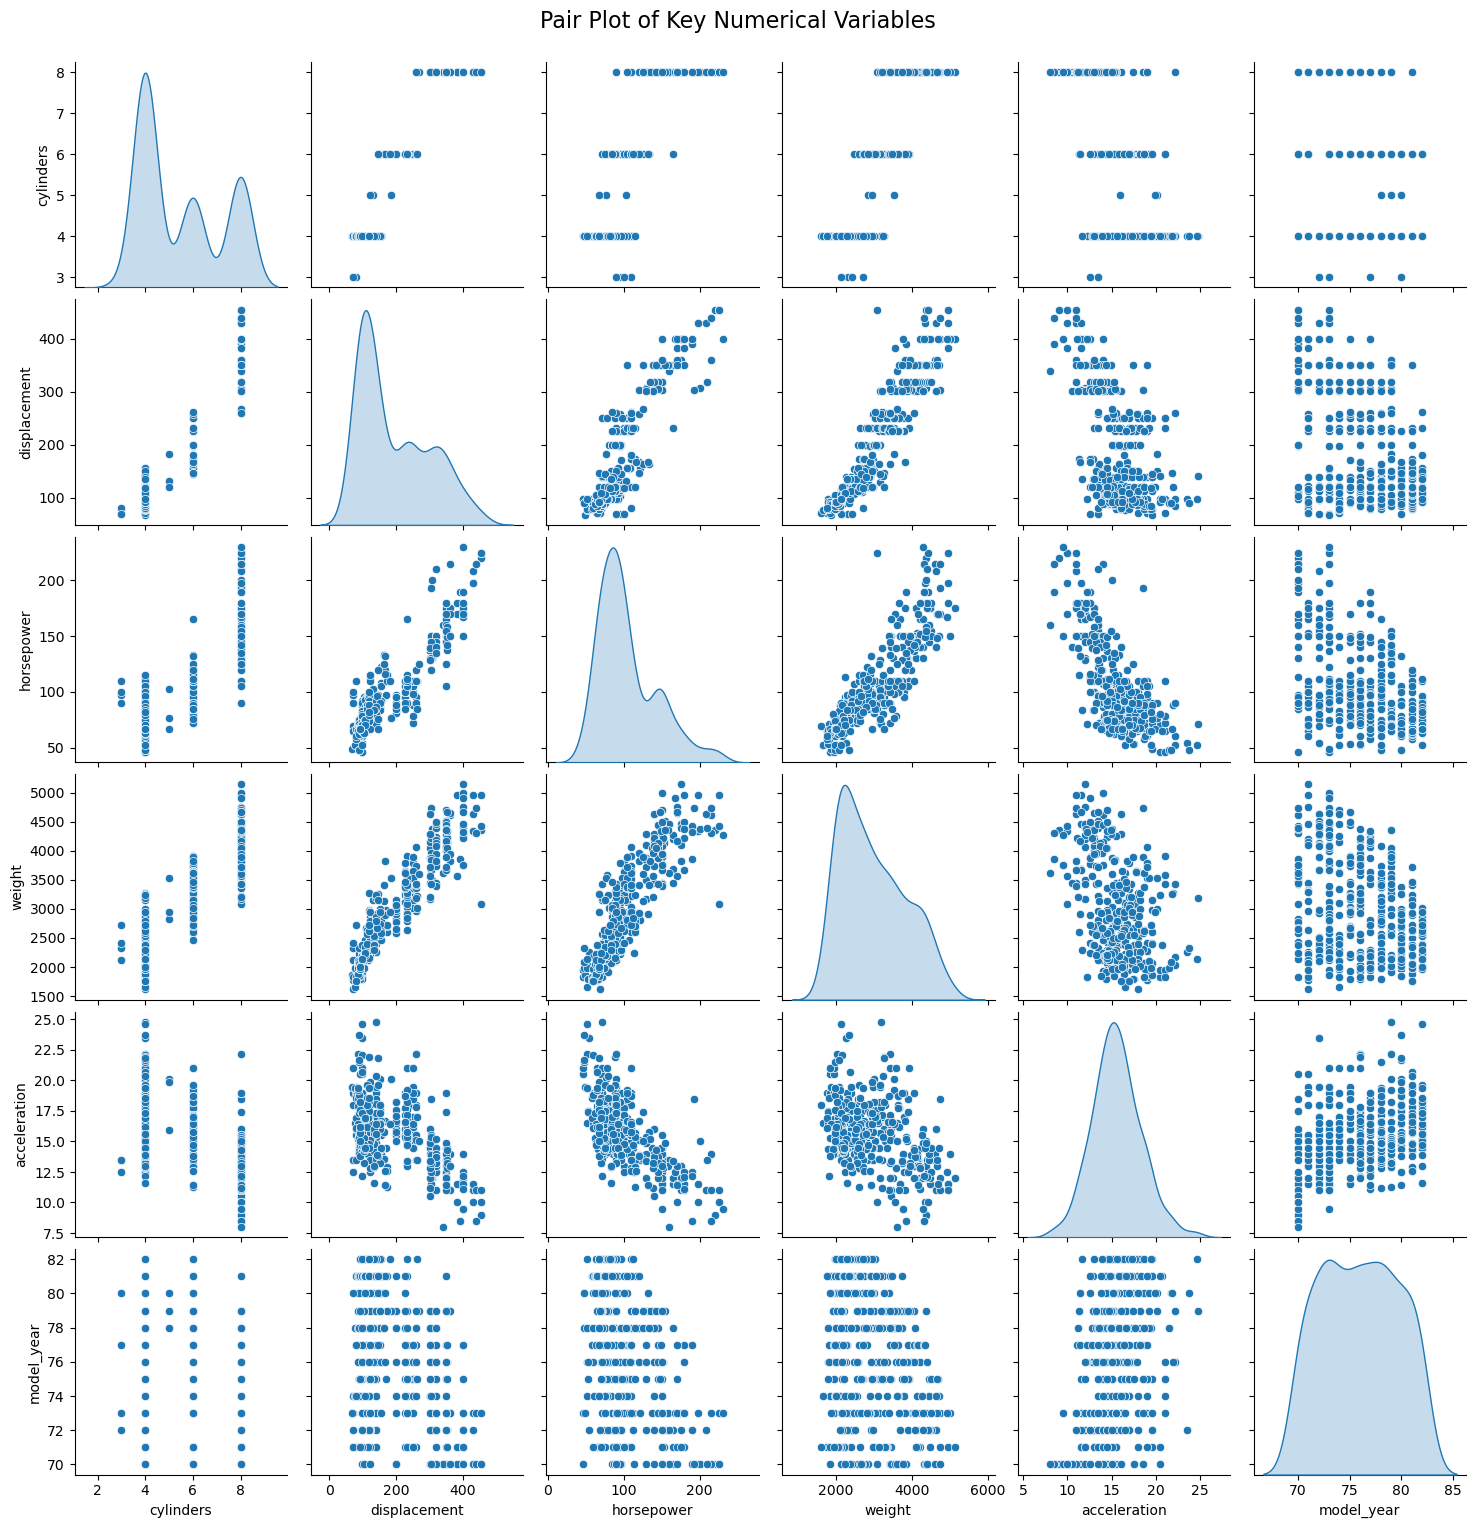

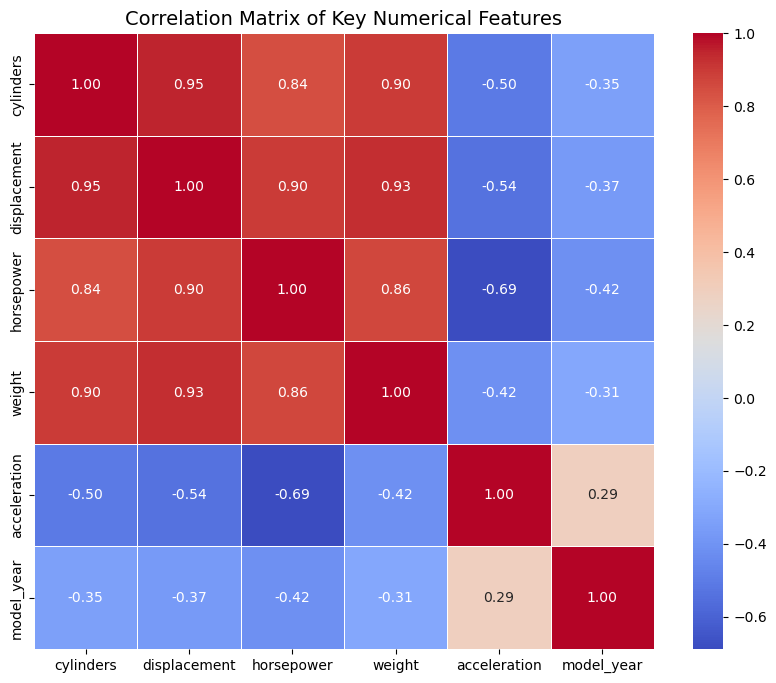

In [11]:
# ===============================================================
# 11. EDA (Visualization)
# ===============================================================

print("--- Exploratory Data Analysis (EDA) Visualizations ---")

# 1. Distribution of MPG
plt.figure(figsize=(10, 5))
sns.histplot(df["mpg"], kde=True, bins=20, color='skyblue')
plt.title("Distribution of MPG", fontsize=14)
plt.xlabel("Miles Per Gallon (MPG)")
plt.show()

# 2. Pair Plot: Visualize relationships between key numerical variables
# Includes the target 'mpg' and the strongest numerical predictors
sns.pairplot(df[numeric_features], diag_kind='kde')
plt.suptitle("Pair Plot of Key Numerical Variables", y=1.02, fontsize=16)
plt.show()

# 3. Correlation Heatmap: Shows linear relationships between numerical features
plt.figure(figsize=(10, 8))
# We explicitly select the numerical features for correlation calculation
sns.heatmap(df[numeric_features].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=.5)
plt.title("Correlation Matrix of Key Numerical Features", fontsize=14)
plt.show()

Run various model in one go !

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Define the models to be tested
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=8),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=4)
}

results = {}

print("\n--- Model Training and Cross-Validation ---")

for name, model in models.items():
    # Create the full pipeline: Preprocessor -> Model
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # 3a. Train the model
    full_pipeline.fit(X_train, y_train)

    # 3b. Evaluate using Cross-Validation (on training data)
    # Cross-validation gives a more robust estimate of performance
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_cv = np.sqrt(-cv_scores.mean())

    # 3c. Predict and Evaluate on the unseen Test Set
    y_pred = full_pipeline.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test = r2_score(y_test, y_pred)

    results[name] = {
        'Test R2': r2_test,
        'Test RMSE': rmse_test,
        'CV RMSE (5-fold)': rmse_cv
    }

    print(f"\nModel: {name}")
    print(f"  CV RMSE: {rmse_cv:.3f}")
    print(f"  Test RMSE: {rmse_test:.3f}")
    print(f"  Test R²: {r2_test:.3f}")

# --- 4. Final Comparison and Conclusion ---

print("\n--- Summary of All Models ---")
results_df = pd.DataFrame(results).T # Transpose the results dictionary for better viewing
results_df = results_df.sort_values(by='Test R2', ascending=False)
print(results_df)

print("\nConclusion:")
best_model = results_df.index[0]
print(f"The **{best_model}** performed best on the unseen test data, achieving an R² of {results_df['Test R2'][0]:.3f}.")
print("It explains the highest percentage of the variance in MPG.")


--- Model Training and Cross-Validation ---

Model: Linear Regression
  CV RMSE: 4.345
  Test RMSE: 3.892
  Test R²: 0.703

Model: Random Forest Regressor
  CV RMSE: 3.047
  Test RMSE: 2.357
  Test R²: 0.891

Model: Gradient Boosting Regressor
  CV RMSE: 3.012
  Test RMSE: 2.489
  Test R²: 0.879

--- Summary of All Models ---
                              Test R2  Test RMSE  CV RMSE (5-fold)
Random Forest Regressor      0.891192   2.356609          3.046601
Gradient Boosting Regressor  0.878605   2.489192          3.012045
Linear Regression            0.703221   3.892011          4.345307

Conclusion:
The **Random Forest Regressor** performed best on the unseen test data, achieving an R² of 0.891.
It explains the highest percentage of the variance in MPG.


C:\Users\jpdob\AppData\Local\Temp\ipykernel_218952\3600221356.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"The **{best_model}** performed best on the unseen test data, achieving an R² of {results_df['Test R2'][0]:.3f}.")


Predictive analysis for the MPG dataset, using multiple ML regression algorithms:

✔ Linear Regression
✔ Random Forest Regressor
✔ Gradient Boosting Regressor
✔ XGBoost Regressor (optional if installed)
✔ Support Vector Regressor (SVR)
✔ K-Nearest Neighbors Regressor
✔ Decision Tree Regressor

All models share a single unified preprocessing pipeline.

In [14]:
# ===============================================================
# 1. Import Libraries
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Try to import XGBoost (if available)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False


In [15]:
# ===============================================================
# 2. Load Dataset
# ===============================================================

df = sns.load_dataset("mpg").dropna()
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

df = df.dropna(subset=['mpg'])
df.reset_index(drop=True, inplace=True)

print("Shape:", df.shape)
print(df.head())

Shape: (392, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [16]:
# ===============================================================
# 3. Feature Selection
# ===============================================================

X = df.drop(columns=['mpg'])
y = df['mpg']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numeric Features:", numeric_cols.tolist())
print("Categorical Features:", categorical_cols.tolist())

Numeric Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Categorical Features: ['origin', 'name']


In [17]:
# ===============================================================
# 4. Preprocessing Pipeline
# ===============================================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


In [18]:
# ===============================================================
# 5. Train-Test Split
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
# ===============================================================
# 6. Model Dictionary
# ===============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel='rbf')
}

if xgb_available:
    models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective='reg:squarederror'
    )


In [20]:
# ===============================================================
# 7. Train, Predict, Evaluate All Models
# ===============================================================

results = []

for name, model in models.items():
    print(f"\nTraining Model: {name}")

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, r2, rmse])

    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")



Training Model: Linear Regression
  R² Score: 0.7032
  RMSE: 3.8920

Training Model: Random Forest
  R² Score: 0.8975
  RMSE: 2.2873

Training Model: Decision Tree
  R² Score: 0.8680
  RMSE: 2.5953

Training Model: KNN Regressor
  R² Score: 0.8557
  RMSE: 2.7139

Training Model: Gradient Boosting
  R² Score: 0.8653
  RMSE: 2.6223

Training Model: Support Vector Regressor
  R² Score: 0.8143
  RMSE: 3.0790

Training Model: XGBoost Regressor
  R² Score: 0.8784
  RMSE: 2.4917


In [21]:
# ===============================================================
# 8. Results Summary Table
# ===============================================================

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
print("\n\n==================== Model Comparison ====================")
print(results_df.sort_values(by="RMSE"))



==================== Model Comparison ====================
                      Model  R2 Score      RMSE
1             Random Forest  0.897503  2.287252
6         XGBoost Regressor  0.878363  2.491675
2             Decision Tree  0.868030  2.595346
4         Gradient Boosting  0.865272  2.622326
3             KNN Regressor  0.855694  2.713942
5  Support Vector Regressor  0.814256  3.079036
0         Linear Regression  0.703221  3.892011



Top Features (Random Forest):
        Feature  Importance
1  displacement    0.414752
2    horsepower    0.165490
3        weight    0.134645
0     cylinders    0.133476
5    model_year    0.094619


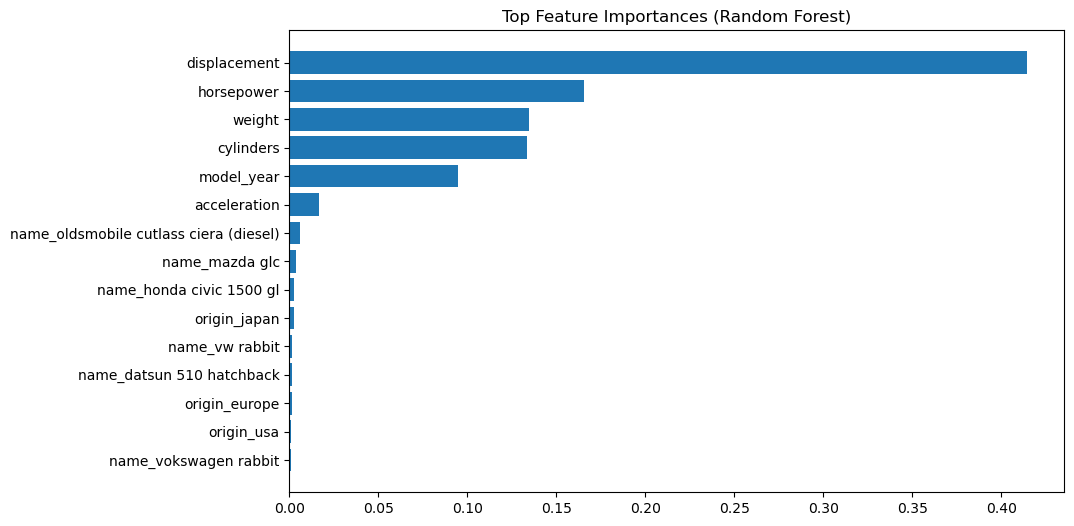

In [22]:
# ===============================================================
# 9. Feature Importance for Tree Models
# ===============================================================

# Example using Random Forest
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])

rf.fit(X_train, y_train)

onehot_features = rf.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_features = list(numeric_cols) + list(onehot_features)

importances = rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Features (Random Forest):")
print(feat_imp.head())

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'].head(15), feat_imp['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.show()


===== BASIC INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 27.7+ KB
None

===== SUMMARY STATISTICS =====
               mpg   cylinders  displacement  horsepower       weight  \
count   392.000000  392.000000    392.000000  392.000000   392.000000   
unique         NaN         NaN           NaN         NaN          NaN   
top            NaN         NaN           NaN         NaN          NaN   


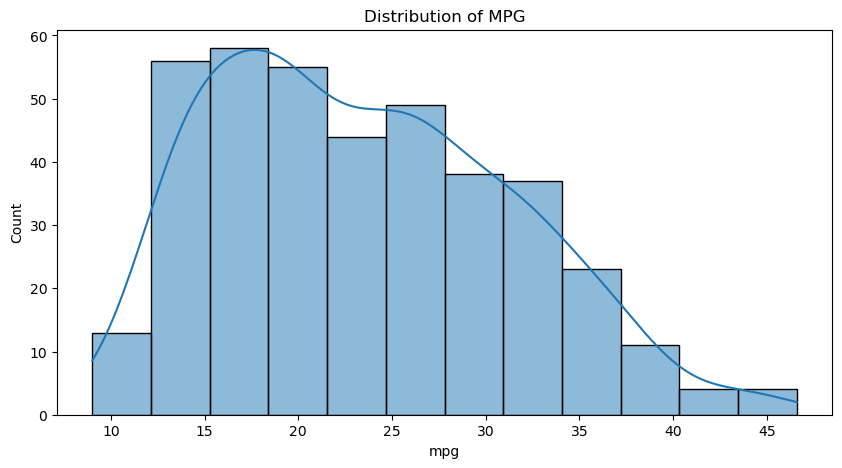

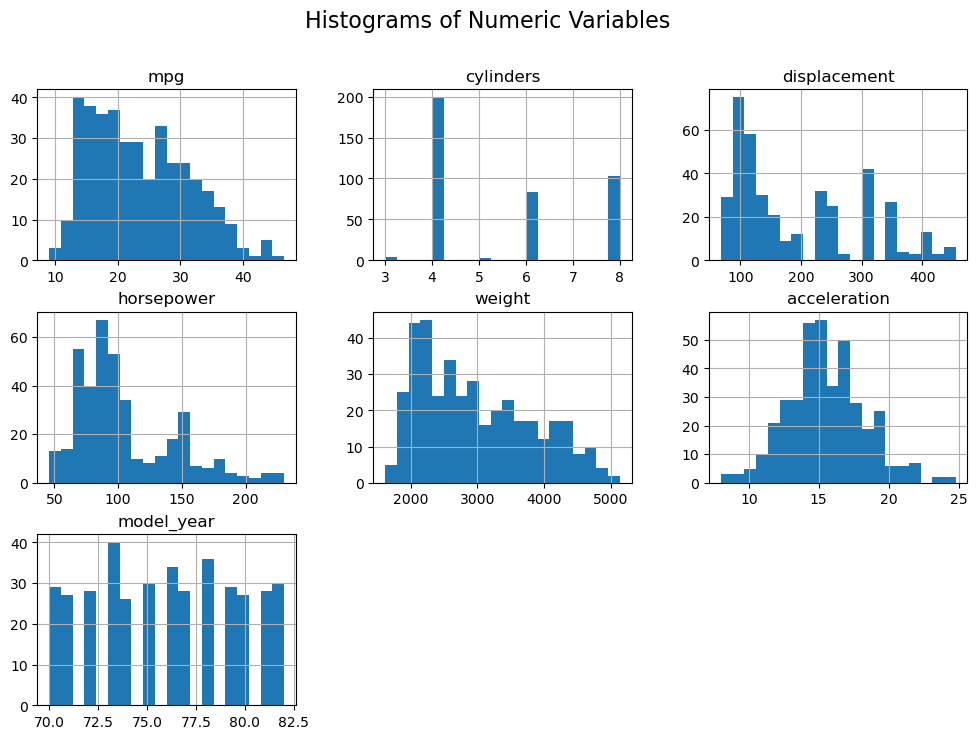

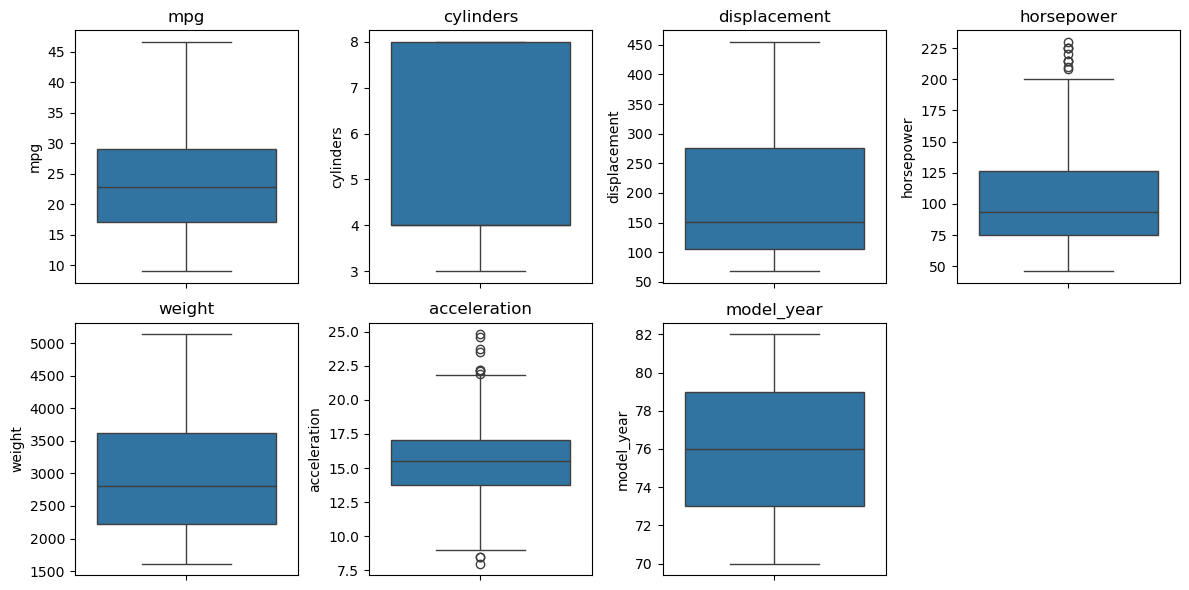

ValueError: could not convert string to float: 'usa'

<Figure size 1000x600 with 0 Axes>

In [23]:
# We can also add analytics before Feature Selection

# ===============================================================
# 2A ========================================= ANALYTICS SECTION
# ===============================================================

print("\n===== BASIC INFORMATION =====")
print(df.info())

print("\n===== SUMMARY STATISTICS =====")
print(df.describe(include="all"))

# -----------------------------------------
# A. Univariate Analysis (Distributions)
# -----------------------------------------

plt.figure(figsize=(10,5))
sns.histplot(df['mpg'], kde=True)
plt.title("Distribution of MPG")
plt.show()

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.show()

# -----------------------------------------
# B. Boxplots (Outlier check)
# -----------------------------------------

plt.figure(figsize=(12,6))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# -----------------------------------------
# C. Correlation Heatmap
# -----------------------------------------

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------
# D. Pairplot for key variables
# -----------------------------------------

sns.pairplot(df[['mpg','horsepower','weight','acceleration','displacement']])
plt.show()

# -----------------------------------------
# E. Relationship Plots
# -----------------------------------------

plt.figure(figsize=(12,4))
sns.scatterplot(x=df['weight'], y=df['mpg'])
plt.title("MPG vs Weight")
plt.show()

plt.figure(figsize=(12,4))
sns.scatterplot(x=df['horsepower'], y=df['mpg'])
plt.title("MPG vs Horsepower")
plt.show()

plt.figure(figsize=(12,4))
sns.scatterplot(x=df['acceleration'], y=df['mpg'])
plt.title("MPG vs Acceleration")
plt.show()